In [ ]:
!pip uninstall -y community
!pip install python-louvain

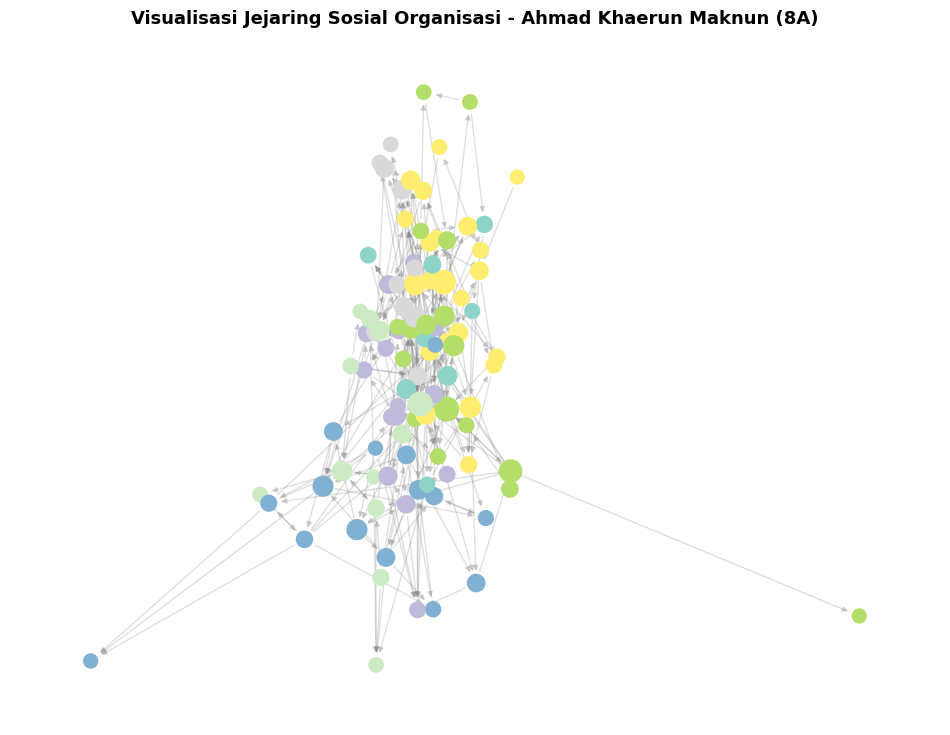

In [ ]:
import community.community_louvain as community_louvain
import matplotlib.pyplot as plt
import networkx as nx

# 1. Inisialisasi Graf Berarah dan Berbobot (N = 100 Node)
G = nx.erdos_renyi_graph(n=100, p=0.03, directed=True, seed=42)

# 2. Perhitungan Metrik Sentralitas Aktor (Soal 2)
in_degree = nx.in_degree_centrality(G)
out_degree = nx.out_degree_centrality(G)
betweenness = nx.betweenness_centrality(G)
closeness = nx.closeness_centrality(G)

# 3. Deteksi Komunitas dengan Algoritma Louvain (Soal 3)
G_undirected = G.to_undirected()
partition = community_louvain.best_partition(G_undirected)

# 4. Visualisasi Grafik (Soal 5)
plt.figure(figsize=(12, 9))
pos = nx.spring_layout(G, seed=42)

# Gunakan colormap bawaan matplotlib
cmap = plt.colormaps['Set3']

# Gambar node berwarna sesuai komunitas, ukuran node sesuai nilai Betweenness
nx.draw_networkx_nodes(
    G,
    pos,
    partition.keys(),
    node_size=[v * 1500 + 100 for v in betweenness.values()],
    node_color=list(partition.values()),
    cmap=cmap,
)
nx.draw_networkx_edges(G, pos, alpha=0.25, arrowsize=8, edge_color='gray')

plt.title(
    'Visualisasi Jejaring Sosial Organisasi - Ahmad Khaerun Maknun (8A)',
    fontsize=13,
    fontweight='bold',
)
plt.axis('off')
plt.show()

# 5. Ekspor Graf ke File GraphML
nx.write_graphml(G, 'jejaring_organisasi_8A.graphml')
print()